###### Content under Creative Commons Attribution license CC-BY 4.0, code under BSD 3-Clause License © 2022  by D. Koehn, T. Meier and J. Stampa, notebook style sheet by L.A. Barba, N.C. Clementi

# Digital Signal Processing in Geophysics 

## Chapter 5 Signal Stacking

In the previous notebook, we calculated the slant stack and the phase velocity frequency spectrum for a shotgather that contained only a direct wave; in this notebook, we will add a refracted wave.

### Synthetic Shot Gather

First, we will write a code that allows us to calculate simple synthetic shot gathers. This is based on the convolution model of seismic traces introduced at the beginning of Chapter 3. The convolution of the seismic source wavelet with the impulse response (reflectivity/Greens function) of the Earth produced the seismic trace. The impulse response contains the reflection coefficients at the layer boundaries at the times when the reflections occur.

In this example, we assume that a direct wave was recorded, whose travel time curve as a function of the offset $x$ and a constant S-wave velocity of a layer above the half-space $vs_0$ can be described by the equation

\begin {equation}
t_{dir} = x / vs_0.  \notag
\end{equation}

In the following, we assume a true S-wave velocity of the first layer of $vs_0 = 200\; m/s$.

In addition to the direct wave, a refracted wave is also expected to occur, which is to propagate at the half-space velocity $vs_1$ according to the following travel time curve:

\begin{equation}
t_{ref} = x / vs_1  + t_0 \notag
\end{equation}

For the true S-wave velocity of the half-space, we assume $vs_1 = 350\; m/s$, and $t_0 = 0.013\; s$. The refracted wave first appears at the critical point in the shot gather, in this case $x_{crit} = 6\; m$. 

The acquisition geometry consists of a profile with a maximum offset $x_{max} = 25\; m$ and receiver spacing of $dx = 0.5\; m$. The maximum recording time of the seismograms is $t_{max} = 0.2\; s$, and the temporal sampling interval is $dt = 125\; \mu s$.

To calculate the seismogram, we must finally define the source wavelet $w$, which is to be convolved with the impulse response of the subsurface. In this case, we use the first derivative of the Gaussian function:

\begin{equation}
w = - 2 \sigma t_s e^{-(\sigma t_s)^2}  \notag
\end {equation}

Here, the half-width $\sigma = 4 f_0$ is related to the dominant frequency of the source wavelet $f_0$, while $t_s=t-t_0$ specifies a time shift of the source wavelet. In this case, we relate the time shift to the dominant frequency of the source wavelet $t_0 = 1/f_0$. The dominant frequency of the source wavelet is set to $f_0 = 40\;Hz$.

Using these parameters, we can calculate the synthetic shot gather $TT$ ...

In [1]:
# Import Python libraries
# -----------------------
#%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def create_shotgather():
    
    # Define acquisition parameters
    xmax = 25.               # maximum offset [m]
    dx = 0.5                 # spatial geophone sampling [m]
    
    tmax = 0.2               # maximum recording time [s]
    dt = 1.25e-4             # time sampling [s]
    
    # Initialize shot gather
    x = np.arange(0, xmax+dx, dx) # offsets [m]
    t = np.arange(0, tmax+dt, dt) # time [s]  
    
    # Compute impulse response of direct & refracted SH wave 
    # ------------------------------------------------------
    # compute travel times of direct SH wave
    vs0 = 200.     # true SH wave velocity of 1st layer
    td = (x / vs0) # traveltime [s]
    nd = (td/dt)   # traveltime [sample#]
    nd = nd.astype(np.int32) # convert floats to integers
    
    # compute travel times of refracted SH wave
    vs1 = 350.               # true SH wave velocity of half-space
    t0 = .013                # t0 time
    tr = (x / vs1) + t0      # traveltime [s]    
    nr = (tr/dt)             # traveltime [sample#]
    nr = nr.astype(np.int32) # convert floats to integers
    
    # add spikes at direct wave first  arrival times
    nx = len(x)             # compute number of receivers
    nt = len(t)             # compute time samples
    TT = np.zeros((nx,nt))  # initialize shot gather as matrix
    
    for i in range(0,nx):
        
        # add direct wave
        TT[i,nd[i]] = 1.
        
        # add refracted wave
        if(i>=(int)(nx//4)):
            TT[i,nr[i]] = 1.
    
    # Define source wavelet 
    # ---------------------
    f0 = 40         # Frequency (Hz)
    p=1./f0          # period
    t0 = p/dt        # defining t0
    sigma=4./p      

    # Initialization of source wavelet
    w=np.zeros(nt) 

    # Initialization of first derivative of gaussian
    for it in range(nt):
        ts=(it-t0)*dt
        w[it]=-2*sigma*ts*np.exp(-(sigma*ts)**2)
    
    # Convolve source wavelet with Greens function
    # --------------------------------------------
    for i in range(0,nx):
        conv = np.convolve(w,TT[i,:])
        TT[i,:] = conv[1:nt+1]
    
    return x,t,TT

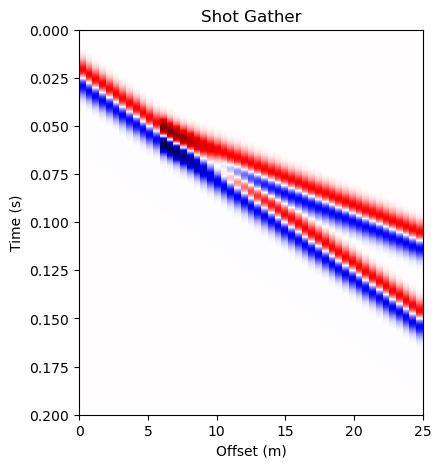

In [4]:
x,t,TT = create_shotgather()

# Initialize Plots
plt.figure(figsize=(10,5))
    
# Plot shot gather
plt.imshow(TT.T, cmap=plt.cm.seismic, interpolation='none', 
                extent=[np.min(x),np.max(x),np.max(t),np.min(t)],aspect=140)
plt.xlabel('Offset (m)')
plt.ylabel('Time (s)')
title = r'Shot Gather'
plt.title(title);

### NMO Correction 

As can be seen, the convolution model can be used to generate a simple synthetic dataset. In the next step, we will calculate the **Normal Move Out (NMO)** of linear events (direct & refracted waves) for various test velocities $vstack$ using the formula 

\begin{equation}
\Delta t_{NMO} = - \frac{x}{vstack}\notag
\end{equation}

and stack the corrected seismic traces according to 

\begin{equation}
\mbox{stack}(t) = \frac{1}{M} \sum_{i=1}^M x_i(t+\Delta t_{NMO}). \notag
\end{equation}

In [5]:
def NMO_corr(vstack,stackcorr):
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    if(stackcorr==True):
        
        # NMO correction by dtNMO = - offset / vstack 
        # --------------------------------------------------------
        TTc = np.zeros((nx,nt))  # initialize corrected shot gather
        tstack = (x / vstack)    # traveltime [s]
        nc = (tstack/dt)         # traveltime [sample#]
        nc = nc.astype(np.int32)   # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        
        TT = TTc
        
    # Initialize Plots
    plt.figure(figsize=(10,5))
    
    plt.subplot(121)
    
    # Plot shot gather
    plt.imshow(TT.T, cmap=plt.cm.seismic, interpolation='none', 
                   extent=[np.min(x),np.max(x),np.max(t),np.min(t)],aspect=140)
    plt.xlabel('Offset (m)')
    plt.ylabel('Time (s)')
    title = r'Shot Gather'
    plt.title(title)
    
    plt.subplot(122)
    
    # Stack data along offsets
    stack = np.sum(TT,0) / nx
    
    # Plot stack
    plt.plot(np.flip(stack), np.flip(t), 'b')
    plt.xlabel('Stack Amplitude ()')
    plt.title('Stack')
    plt.xlim(-1.,1.)
    plt.ylim(np.min(t),np.max(t))
    plt.gca().invert_yaxis()

In [8]:
interactive_plot = interactive(NMO_corr, vstack=(110., 500., 10.), stackcorr=False )
output = interactive_plot.children[-1]
output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=300.0, description='vstack', max=500.0, min=110.0, step=10.0), Checkbo…

### Slant Stack 

Based on the `NMO_corr` function, we can program a function that calculates the **slant stack** of a shot gather. To do this, we simply apply the NMO correction for different stacking velocities $vstack$ to the shot gather and save the stacked stacks for each velocity. If we plot the times against the stacks, we obtain the slant stack ...

In [9]:
def slant_stack():
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    # Compute Slant Stack
    # -------------------
    
    # define array for stacking velocities
    vstack = np.arange(100.,500.,10.)
    nv = len(vstack) # number of tested velocities
    
    # initialize slant stack with zeros
    sstack = np.zeros((nv,nt))
    
    # loop over velocities
    for k in range(0,nv) :
        
        # NMO correction by dtNMO = - offset / vstack 
        TTc = np.zeros((nx,nt))  # initialize corrected shot gather
        tstack = (x / vstack[k])    # traveltime [s]
        nc = (tstack/dt)         # traveltime [sample#]
        nc = nc.astype(np.int32)   # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        # Stack NMO corrected data
        stack = np.sum(TTc,0) / nx
            
    
        # update slant stack
        sstack[k,:] = stack[:]
    
    
    # Initialize Plots
    plt.figure(figsize=(10,5))
    
    # Plot slant stack
    plt.imshow(sstack.T, cmap=plt.cm.seismic, interpolation='none', 
                   extent=[np.min(vstack),np.max(vstack),np.max(t),np.min(t)],aspect=1e3)
    plt.xlabel('vstack (m/s)')
    plt.ylabel(r'$\tau$ (s)')
    title = r'Slant Stack'
    plt.title(title)
    
    return sstack

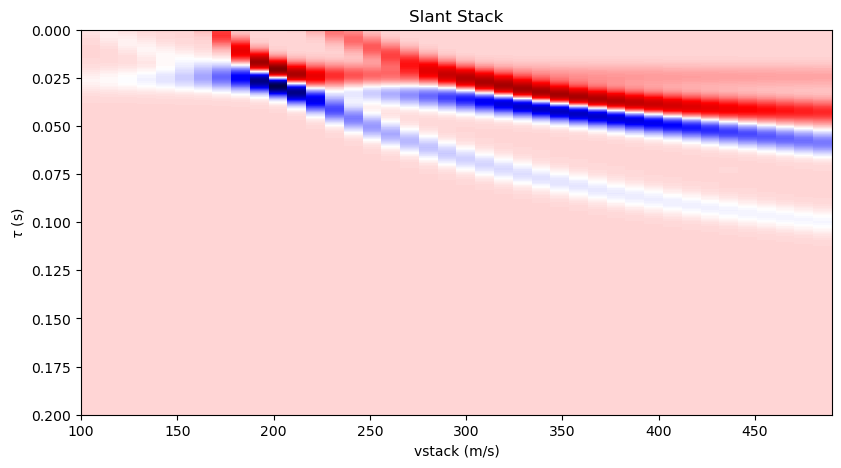

In [10]:
sstack = slant_stack()

### Phase-velocity frequency spectra

If we compute the Fourier transform of the time axis, we obtain the **phase-velocity frequency spectrum**. This can be easily implemented in our Slant-Stack code ...

In [11]:
def pf_spec():
    
    # create data
    x,t,TT = create_shotgather()
    
    # Define parameters
    nx = len(x)
    nt = len(t)
    dt = t[1]-t[0]
    
    # Compute Slant Stack
    # -------------------
    
    # define array for stacking velocities
    vstack = np.arange(100.,500.,10.)
    nv = len(vstack) # number of tested velocities
    
    # initialize slant stack with zeros
    sstack = np.zeros((nv,nt))
    
    # loop over velocities
    for k in range(0,nv) :
        
        # NMO correction by dtNMO = - offset / vstack 
        TTc = np.zeros((nx,nt))    # initialize corrected shot gather
        tstack = (x / vstack[k])   # traveltime [s]
        nc = (tstack/dt)           # traveltime [sample#]
        nc = nc.astype(np.int32)   # convert floats to integers
    
        for i in range(0,nx):
            for j in range(0,nt):
            
                if((j+nc[i]) < nt):
                    TTc[i,j] = TT[i,j+nc[i]]
    
        # Stack NMO corrected data
        stack = np.sum(TTc,0) / nx
            
        # update slant stack
        sstack[k,:] = stack[:]
    
    # Compute pf-spectrum
    # -------------------
    
    # Fourier transform slant stack along the time axis
    pf = np.fft.fft(sstack)
    
    # Normalize by length of the time series
    pf = pf / (nt*dt)
    
    # estimate frequencies    
    freq = np.fft.fftfreq(nt, d=dt)
    
    # Initialize Plots
    plt.figure(figsize=(10,5))
    
    # Plot pf spectrum
    levels = np.linspace(0., np.max(np.abs(pf)), num=1000)
    plt.contourf(freq,vstack,np.abs(pf),levels=levels,cmap='magma')
    
    plt.ylabel('Phase velocity vstack (m/s)')
    plt.xlabel(r'Frequency (Hz)')
    title = r'Phasevelocity-Frequency Spectrum'
    plt.title(title)
    plt.xlim(0.,100.)

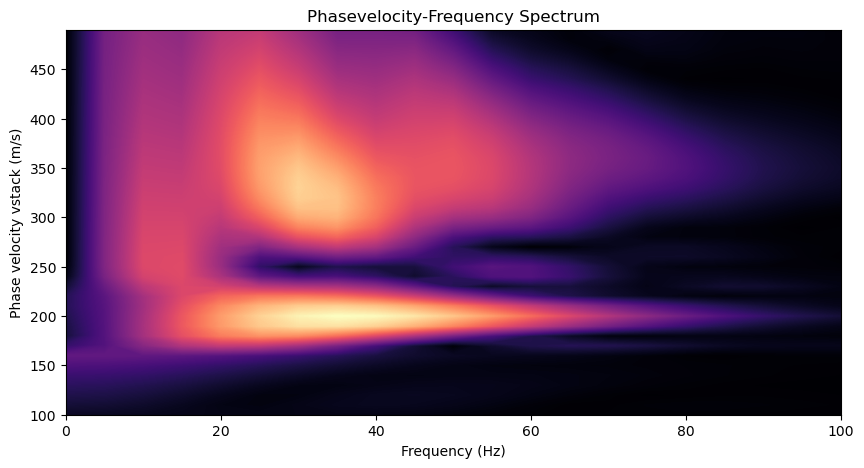

In [12]:
pf_spec()

## Summary:

- We calculated the slant stack and the phase velocity frequency spectrum for a more complex shot gather consisting of a direct wave and a refracted wave.